In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)
 
        ##############################################################################################
        # Custom function for a plot with 7 labels.
        # If it does not looks good for your data, try this function instead:
        # def set_varlabels(self, labels):
        #     self.set_thetagrids(np.degrees(theta), labels)
        def set_varlabels(self, labels):
            angles_deg = np.degrees(theta)
            self.set_thetagrids(angles_deg, labels)

            for idx, (angle, label) in enumerate(zip(angles_deg, self.get_xticklabels())):
                label.set_fontsize(14)
                label.set_verticalalignment("center")
                label.set_horizontalalignment("center")

                if abs(angle) < 1 or abs(angle - 180) < 10 or abs(angle - 360) < 1:
                    continue

                if idx == 5:
                    offset = - 0.075 
                else:
                    offset = - 0.055

                label.set_position((label.get_position()[0], label.get_position()[1] + offset))
        ##############################################################################################

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                spine = Spine(axes=self, spine_type='circle', path=Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

def parse_mrr_file(eval_file, inference_file):
    """Extract MRR values from a YAML file."""
    mrr_values = {}

    with open(eval_file, 'r') as file:
        data = yaml.safe_load(file)
        
        mrr_values["global_mrr"] = data.get("Global_MRR", 0)
        mrr_values["made_directed_relations"] = data.get("made_directed_relations", {}).get("Global_MRR", 0)
        mrr_values["target_relations"] = data.get("target_relations", {}).get("Global_MRR", 0)
        mrr_values['target_frequent'] = data.get('target_relations_by_frequency',{}).get('indication',{}).get('Frequent_MRR', 0)
        mrr_values['target_infrequent'] = data.get('target_relations_by_frequency',{}).get('indication',{}).get('Infrequent_MRR', 0)
        
    with open(inference_file, 'r') as file:   
        data = yaml.safe_load(file)

        mrr_values['inference_mrr'] = data.get('Inference MRR', 0)

    # Load training_metrics.csv and get best validation MRR
    csv_file = os.path.join(os.path.dirname(eval_file), 'training_metrics.csv')
    if os.path.exists(csv_file):
            df = pd.read_csv(csv_file)
            if 'Validation MRR' in df.columns:
                mrr_values['validation_mrr'] = df['Validation MRR'].max()
            else:
                mrr_values['validation_mrr'] = -1

    return mrr_values

def parse_model_metrics(base_dirs):
    models_data = {}

    for key, dl_dir in base_dirs.items():
        dl_path = dl_dir
        models_data[key] = {}

        for run in ['run1', 'run2']:
            run_path = os.path.join(dl_path, run)
            models_data[key][run] = {}

            for dirpath, dirnames, filenames in os.walk(run_path):
                if 'evaluation_metrics.yaml' in filenames and 'inference_metrics.yaml' in filenames:
                    model_name = os.path.basename(dirpath)

                    eval_file = os.path.join(dirpath, 'evaluation_metrics.yaml')
                    inference_file = os.path.join(dirpath, 'inference_metrics.yaml')

                    mrr_values = parse_mrr_file(eval_file, inference_file)

                    models_data[key][run][model_name] = mrr_values

        # Now compute best metrics across runs  
        models_data[key]["best"] = {}
        all_models = set(models_data[key]['run1'].keys()).union(models_data[key]['run2'].keys())

        for model in all_models:
            best_metrics = {}
            for metric in ['global_mrr', 'made_directed_relations', 'target_relations', 'target_frequent', 'target_infrequent', 'inference_mrr', 'validation_mrr']:
                val1 = models_data[key]['run1'].get(model, {}).get(metric, 0)
                val2 = models_data[key]['run2'].get(model, {}).get(metric, 0)
                best_metrics[metric] = max(val1, val2)
            models_data[key]["best"][model] = best_metrics

    return models_data

def plot_radar(results, 
               experiment1, 
               run,
               metric1, 
               experiment2=None, 
               metric2=None, 
               y_lim=0.7, 
               title="Radar Plot", 
               legend_labels=None, 
               colors=("red", "blue"), 
               font_size=14, 
               desired_order=["ANALOGY", "ComplEx", "HolE", "RESCAL", "DistMult", "TransE", "TransD"], 
               rgrid=None, 
               markers=False,
               savefile=None,
               savedir=".",
               saveformat='svg',
               show=True,
               ax=None):
    
    if experiment2 and experiment2 != experiment1 and metric2 is None:
        comparison_type = "exp"
        metric2 = metric1
    elif experiment2 is None and metric2 and metric2 != metric1:
        comparison_type = "metric"
        experiment2 = experiment1
    elif experiment2 is None and metric2 is None:
        comparison_type = "single"
        experiment2 = experiment1
        metric2 = None
    else:
        raise ValueError("Invalid combination of arguments.")

    for exp in [experiment1, experiment2]:
        if exp not in results:
            raise ValueError(f"Experiment '{exp}' not found in the results.")
        if run not in results[exp]:
            raise ValueError(f"Run '{run}' not found in experiment '{exp}'.")

    models = list(results[experiment1][run].keys())
    models = [m for m in desired_order if m in models]
    N = len(models)
    theta = radar_factory(N, frame='polygon')

    values_1 = [results[experiment1][run][m][metric1] for m in models]
    values_2 = [results[experiment2][run][m][metric2] for m in models] if comparison_type != "single" else None

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='radar'))
    else:
        fig = plt.gcf()
    ax.set_ylim(0, y_lim)

    if rgrid is None:
        rgrid = np.arange(0, y_lim, 0.1)
    ax.set_rgrids(rgrid, angle=np.degrees(theta[N-1]), ha='center', color='grey', fontsize=font_size)

    ax.set_title(title, ha='center', fontsize=font_size + 2, weight='bold', pad=15)

    if comparison_type == "exp":
        legend1 = legend_labels[0] if legend_labels else experiment1
        legend2 = legend_labels[1] if legend_labels else experiment2
    elif comparison_type == "metric":
        legend1 = legend_labels[0] if legend_labels else metric1
        legend2 = legend_labels[1] if legend_labels else metric2
    else:
        legend1 = legend_labels[0] if legend_labels else f"{experiment1} - {metric1}"
        legend2 = None

    ax.plot(theta, values_1, color=colors[0], label=legend1)
    if markers:
        ax.scatter(theta, values_1, color=colors[0], alpha=0.8, s=40, marker='v')
        
    if values_2:
        ax.plot(theta, values_2, color=colors[1], label=legend2)
        if markers:
            ax.scatter(theta, values_2, color=colors[1], alpha=0.8, s=40, marker='o')
    ax.set_varlabels(models)
    for label in ax.get_xticklabels():
        label.set_fontsize(font_size)

    lines, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=font_size)


    if savefile is None:
        if comparison_type == "exp":
            savefile = f"radar_{experiment1}_vs_{experiment2}_{metric1}_{run}.{saveformat}"
        elif comparison_type == "metric":
            savefile = f"radar_{experiment1}_{metric1}_vs_{metric2}_{run}.{saveformat}"
        else:
            savefile = f"radar_{experiment1}_{metric1}_{run}.{saveformat}"
    else:
        savefile = f"{savefile}.{saveformat}"

    os.makedirs(savedir, exist_ok=True)
    full_path = os.path.join(savedir, savefile)
    print(full_path)

    fig.tight_layout()
    fig.savefig(full_path, format=saveformat, bbox_inches="tight")

    if show:
        plt.show()

    return fig  


In [2]:
results = parse_model_metrics({"with_dl1": '/home/galadriel/dr_benchmark/DL1experiment/withDL1/models', 
                               "without_dl1": '/home/galadriel/dr_benchmark/DL1experiment/withoutDL1/models',
                               "without_dl1_indication": '/home/galadriel/dr_benchmark/DL1experiment/withoutDL1/models_indication',
                               "dl2": '/home/galadriel/dr_benchmark/DL2experiment/models',
                               "dl2_indication": '/home/galadriel/dr_benchmark/DL2experiment/models_indication',
                               "zero_shot": '/home/galadriel/dr_benchmark/DL3experiment/zero_shot/models'})

## FIGURE 1

./radar_with_dl1_vs_without_dl1_global_mrr_best.svg
./radar_with_dl1_vs_without_dl1_made_directed_relations_best.svg
./radar_with_dl1_vs_without_dl1_target_relations_best.svg


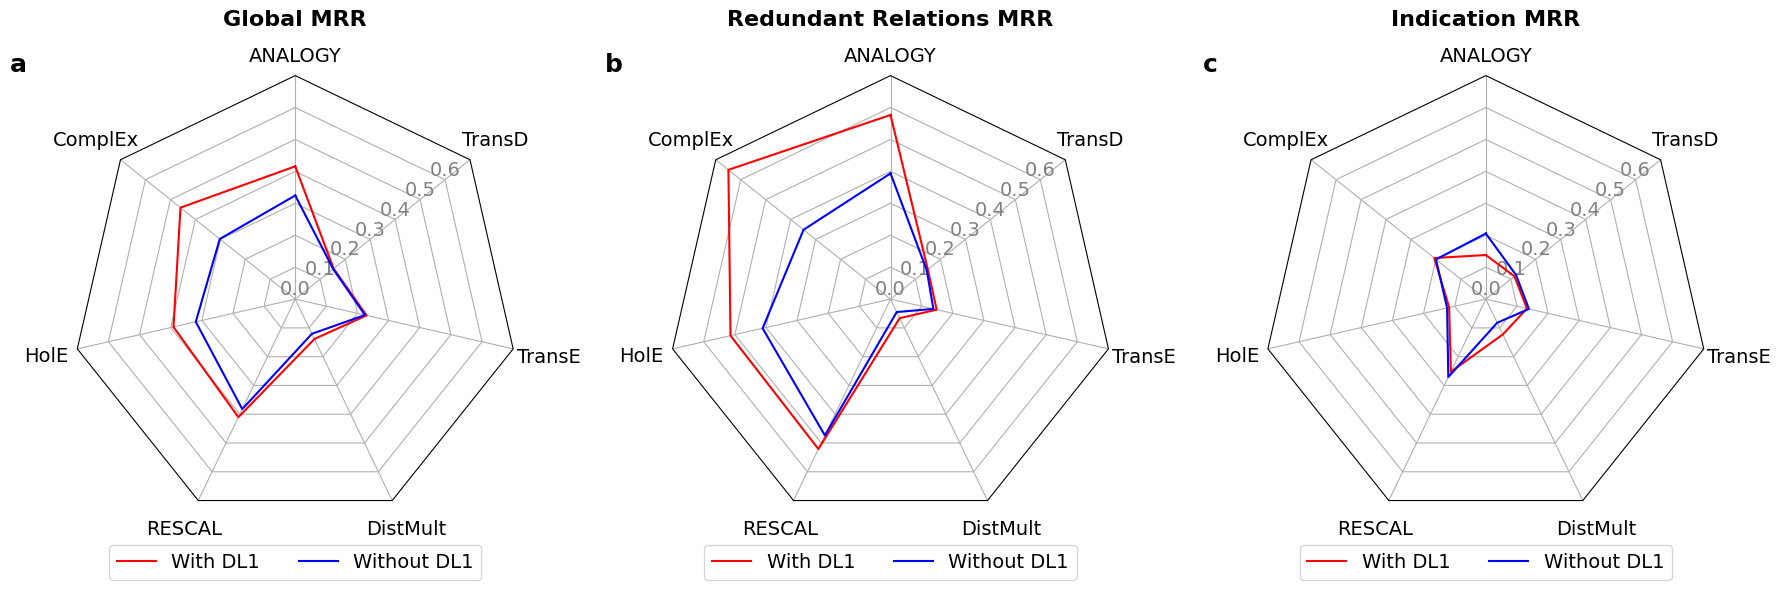

In [3]:
radar_factory(7, frame='polygon')
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='radar'))

titles = ["Global MRR", "Redundant Relations MRR", "Indication MRR"]
metrics = ["global_mrr", "made_directed_relations", "target_relations"]

for i in range(3):
    plot_radar(
        results=results,
        experiment1="with_dl1",
        experiment2="without_dl1",
        run="best",
        metric1=metrics[i],
        y_lim=0.7,
        title=titles[i],
        legend_labels=["With DL1", "Without DL1"],
        colors=("red", "blue"),
        font_size=14,
        markers=False,
        savefile=None,
        show=False,
        saveformat="svg",
        ax=axs[i] 
    )
    axs[i].text(-0.1, 1.05, chr(97 + i), transform=axs[i].transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("../figures/figure1.svg", format="svg", bbox_inches="tight")
plt.show()


In [4]:
# def plot_radar_multi(
#     results,
#     comparisons,
#     y_lim=0.7,
#     title="Radar Plot",
#     legend_labels=None,
#     colors=None,
#     font_size=14,
#     desired_order=["ANALOGY", "ComplEx", "HolE", "RESCAL", "DistMult", "TransE", "TransD"],
#     rgrid=None,
#     markers=False,
#     savefile=None,
#     savedir=".",
#     saveformat='svg',
#     show=True,
#     ax=None
# ):
#     if colors is None:
#         colors = ['red', 'blue', 'green', 'orange', 'purple']

#     # Extract models from first experiment/run in comparisons
#     first_exp, first_run, first_metric = comparisons[0]
#     if first_exp not in results:
#         raise ValueError(f"Experiment '{first_exp}' not found in results")
#     if first_run not in results[first_exp]:
#         raise ValueError(f"Run '{first_run}' not found in experiment '{first_exp}'")

#     models = list(results[first_exp][first_run].keys())
#     # Keep only models in desired order if present
#     models = [m for m in desired_order if m in models]
#     N = len(models)

#     # Create theta once
#     theta = radar_factory(N, frame='polygon')

#     # Create figure and axis if ax not provided
#     if ax is None:
#         fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='radar'))
#     else:
#         fig = ax.figure  # get figure from ax

#     ax.set_ylim(0, y_lim)

#     if rgrid is None:
#         rgrid = np.arange(0, y_lim + 0.01, 0.1)  # +0.01 to include y_lim if exact

#     ax.set_rgrids(rgrid, angle=np.degrees(theta[-1]), ha='center', color='grey', fontsize=font_size)
#     ax.set_title(title, ha='center', fontsize=font_size + 2, weight='bold', pad=15)

#     for idx, (exp, run, metric) in enumerate(comparisons):
#         if exp not in results:
#             raise ValueError(f"Experiment '{exp}' not found in results")
#         if run not in results[exp]:
#             raise ValueError(f"Run '{run}' not found in experiment '{exp}'")

#         values = [results[exp][run][m][metric] for m in models]
#         color = colors[idx % len(colors)]
#         label = legend_labels[idx] if legend_labels and idx < len(legend_labels) else f"{exp}-{metric}"

#         line = ax.plot(theta, values, color=color, label=label)[0]
#         if markers:
#             ax.scatter(theta, values, color=color, alpha=0.8, s=40, marker='o')

#     ax.set_varlabels(models)
#     for label in ax.get_xticklabels():
#         label.set_fontsize(font_size)

#     lines, labels = ax.get_legend_handles_labels()
#     if labels:
#         ax.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(labels), fontsize=font_size)

#     if savefile is None:
#         savefile = f"radar_multi_{title.replace(' ', '_').lower()}.{saveformat}"
#     else:
#         savefile = f"{savefile}.{saveformat}"

#     os.makedirs(savedir, exist_ok=True)
#     full_path = os.path.join(savedir, savefile)
#     print(f"Saving radar plot to: {full_path}")

#     fig.tight_layout()
#     fig.savefig(full_path, format=saveformat, bbox_inches="tight")

#     if show:
#         plt.show()

#     return fig

In [5]:
# plot_radar_multi(
#     results=results,
#     comparisons=[
#         ("with_dl1", "best", "target_relations"),
#         ("without_dl1", "best", "target_relations"),
#         ("zero_shot", "best", "target_relations")
#     ],
#     title="Target Relation MRR: DL1 vs Zero-shot",
#     legend_labels=["With DL1", "Without DL1", "Zero-shot"],
#     colors=["green", "orange", "purple"],
#     y_lim=0.6,
#     savefile="radar_target_relation_dl1_vs_zero_shot",
#     show=True
# )


## FIGURE 2

./radar_without_dl1_vs_dl2_target_relations_best.svg
./radar_without_dl1_vs_dl2_global_mrr_best.svg


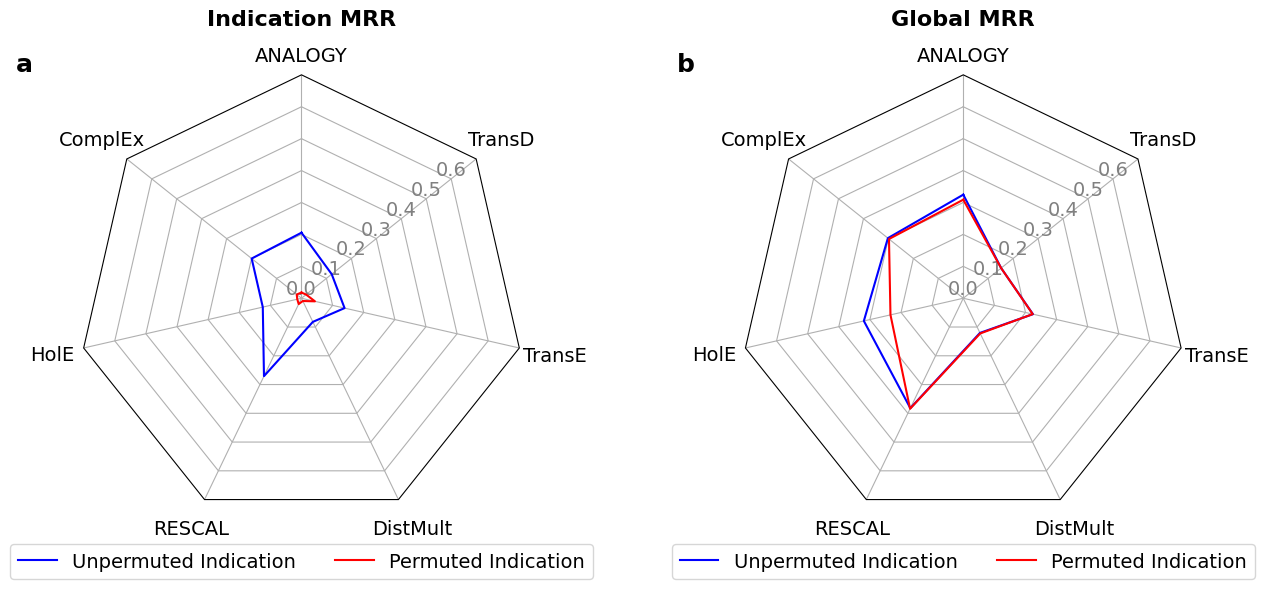

In [6]:
radar_factory(7, frame='polygon')
fig, axs = plt.subplots(1, 2, figsize=(18, 6), subplot_kw=dict(projection='radar'))

titles = ["Indication MRR", "Global MRR"]
metrics = ["target_relations", "global_mrr"]

for i in range(2):
    plot_radar(
        results=results,
        experiment1="without_dl1",
        experiment2="dl2",
        run="best",
        metric1=metrics[i],
        y_lim=0.7,
        title=titles[i],
        legend_labels=["Unpermuted Indication", "Permuted Indication"],
        colors=("blue", "red"),
        font_size=14,
        markers=False,
        savefile=None,
        show=False,
        saveformat="svg",
        ax=axs[i] 
    )
    axs[i].text(-0.1, 1.05, chr(97 + i), transform=axs[i].transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("../figures/figure2.svg", format="svg", bbox_inches="tight")
plt.show()


## FIGURE 3 - Random Splits

./radar_without_dl1_target_relations_vs_inference_mrr_best.svg
./radar_without_dl1_target_frequent_vs_target_infrequent_best.svg


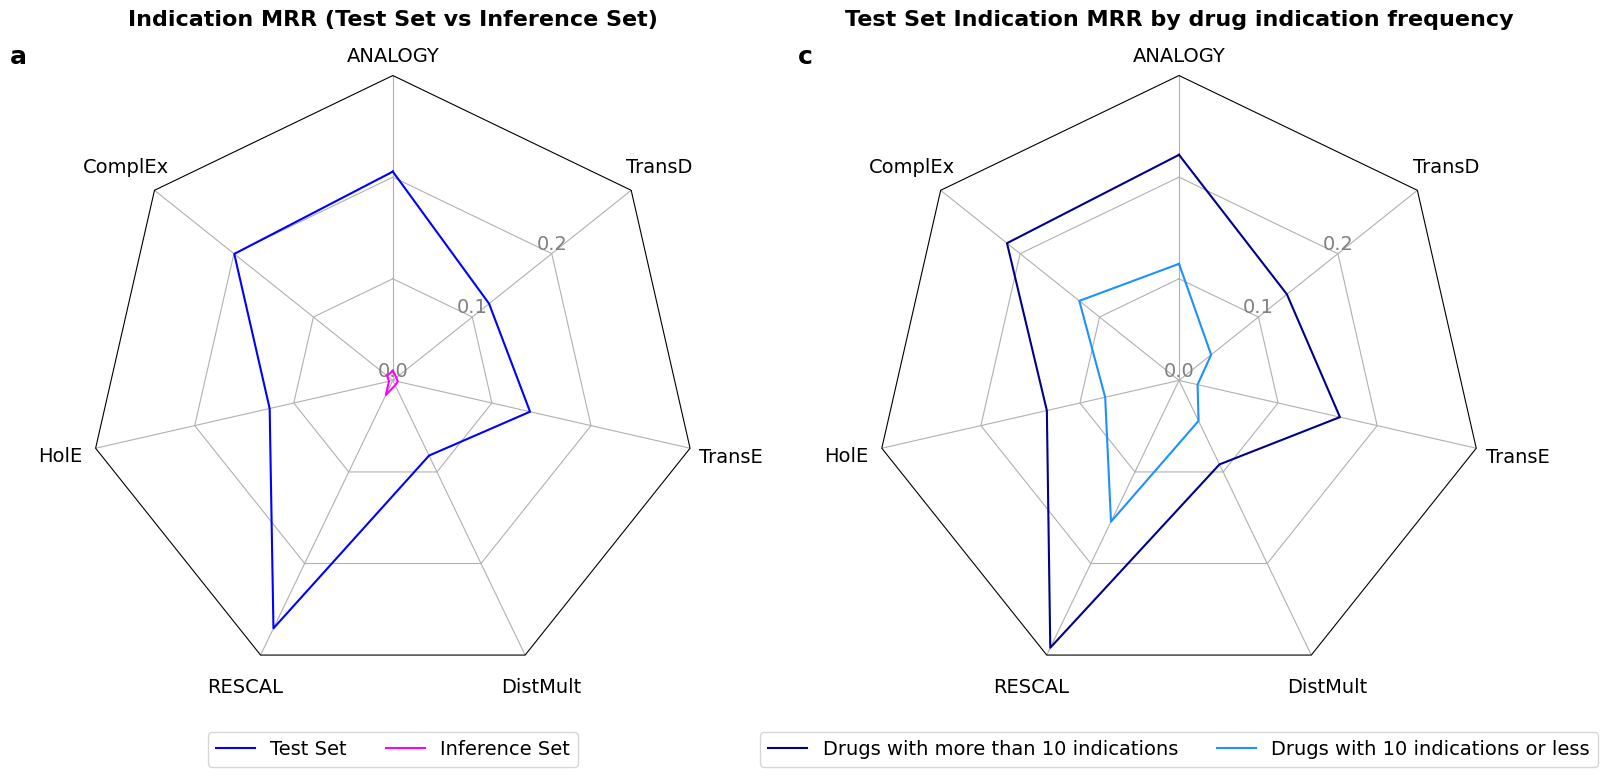

In [7]:
radar_factory(7, frame='polygon')
fig, axs = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='radar'))

# Plot 1: Test vs Inference MRR
plot_radar(
    results=results,
    experiment1="without_dl1",
    run="best",
    metric1="target_relations",
    metric2="inference_mrr",
    y_lim=0.3,
    title="Indication MRR (Test Set vs Inference Set)",
    legend_labels=["Test Set", "Inference Set"],
    colors=("blue", "fuchsia"),
    font_size=14,
    markers=False,
    savefile=None,
    show=False,
    saveformat="svg",
    ax=axs[0]
)
axs[0].text(-0.1, 1.05, 'a', transform=axs[0].transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

# Plot 2: Test Frequent vs Test Infrequent
plot_radar(
    results=results,
    experiment1="without_dl1",
    run="best",
    metric1="target_frequent",
    metric2="target_infrequent",
    experiment2=None,
    y_lim=0.3,
    title="Test Set Indication MRR by drug indication frequency",
    legend_labels=["Drugs with more than 10 indications", "Drugs with 10 indications or less"],
    colors=("darkblue", "dodgerblue"),
    font_size=14,
    markers=False,
    savefile=None,
    show=False,
    saveformat="svg",
    ax=axs[1]
)
axs[1].text(-0.1, 1.05, 'c', transform=axs[1].transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("../figures/figure3-1.svg", format="svg", bbox_inches="tight")
plt.show()


## FIGURE 4 - Cold Start Splits

./radar_without_dl1_indication_vs_zero_shot_target_relations_best.svg
./radar_without_dl1_indication_vs_zero_shot_inference_mrr_best.svg


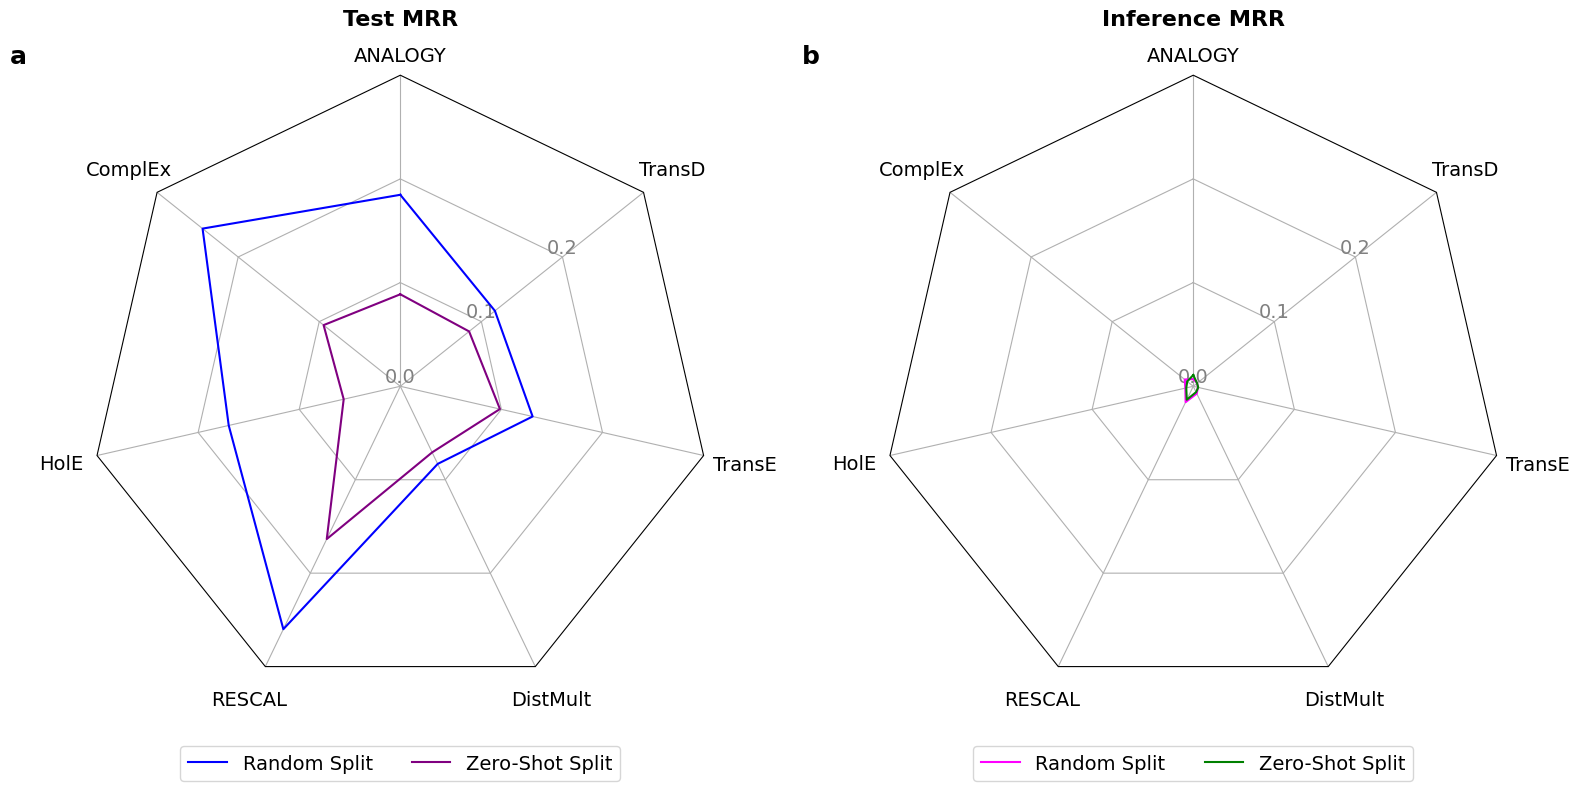

In [8]:
radar_factory(7, frame='polygon')
fig, axs = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='radar'))

# Plot 1: Test 
plot_radar(
    results=results, 
    metric1="target_relations",
    experiment1="without_dl1_indication", 
    experiment2="zero_shot",
    run="best", 
    y_lim=0.3, 
    title="Test MRR", 
    legend_labels=["Random Split", "Zero-Shot Split"], 
    colors=("blue", "purple"), 
    font_size=14,
    saveformat="svg",
    savefile=None,
    show=False,
    ax=axs[0]
)
axs[0].text(-0.1, 1.05, 'a', transform=axs[0].transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

# Plot 2: Inference
plot_radar(
    results=results, 
    metric1="inference_mrr",
    experiment1="without_dl1_indication", 
    experiment2="zero_shot",
    run="best", 
    y_lim=0.3, 
    title="Inference MRR", 
    legend_labels=["Random Split", "Zero-Shot Split"], 
    colors=("fuchsia", "green"), 
    font_size=14,
    saveformat="svg",
    savefile=None,
    show=False,
    ax=axs[1]
)
axs[1].text(-0.1, 1.05, 'b', transform=axs[1].transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("../figures/figure4.svg", format="svg", bbox_inches="tight")
plt.show()


## Generalist VS Specialist

./radar_without_dl1_vs_without_dl1_indication_target_relations_run1.svg


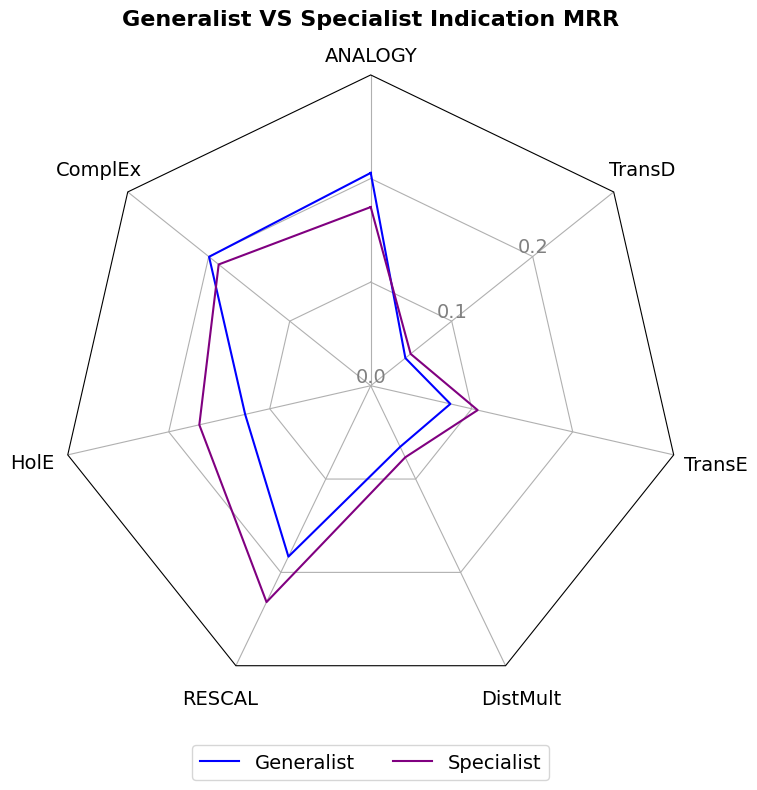

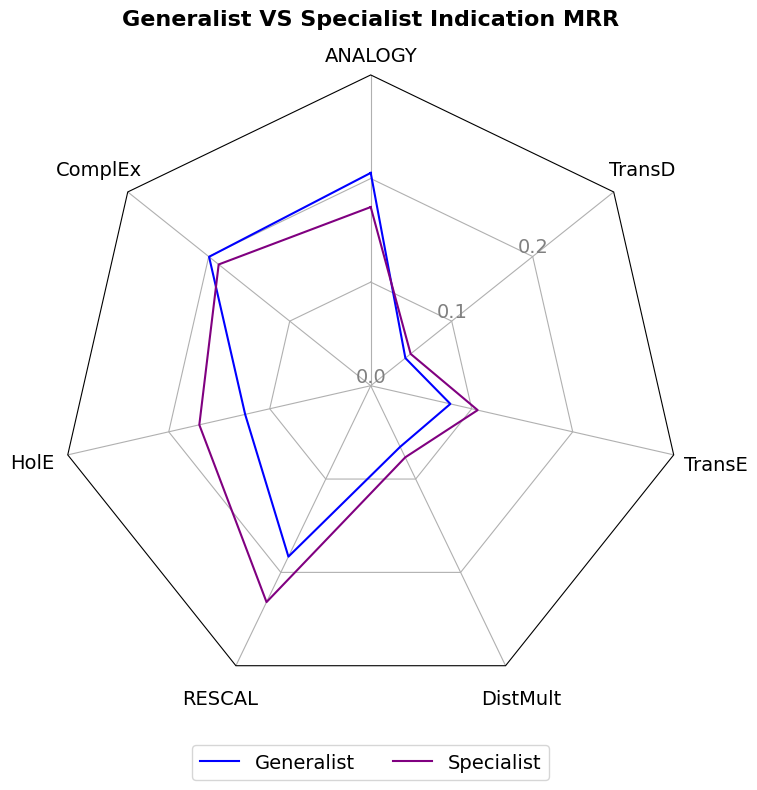

In [9]:
experiment1 = "without_dl1"  
experiment2 = "without_dl1_indication"
run = "run1" 
metric1 = "target_relations"
title = "Generalist VS Specialist Indication MRR"
y_lim=0.3
labels = ["Generalist", "Specialist"]
colors = ("blue", "purple")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
)

./radar_without_dl1_vs_without_dl1_indication_inference_mrr_run1.svg


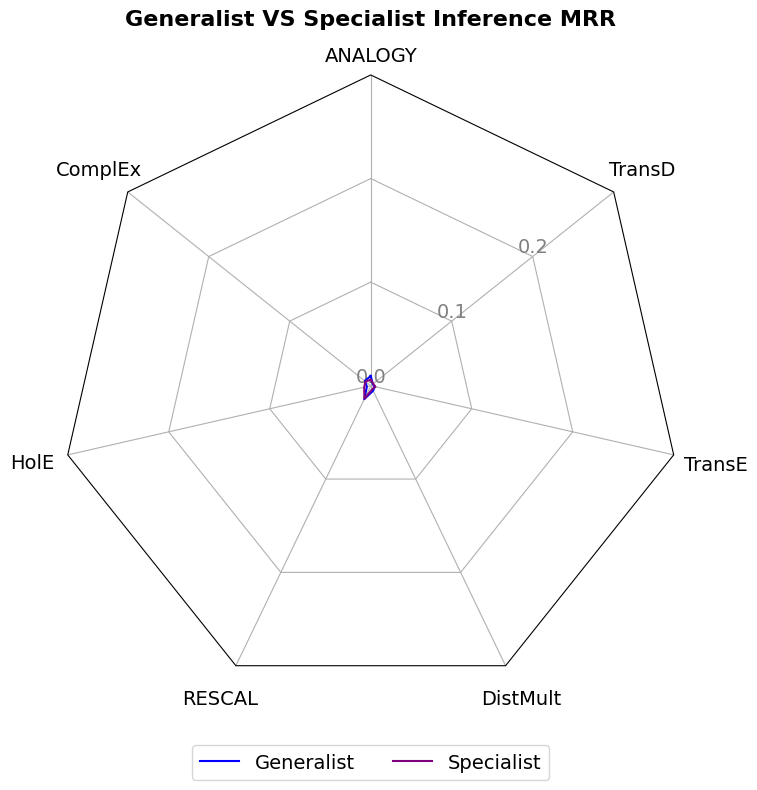

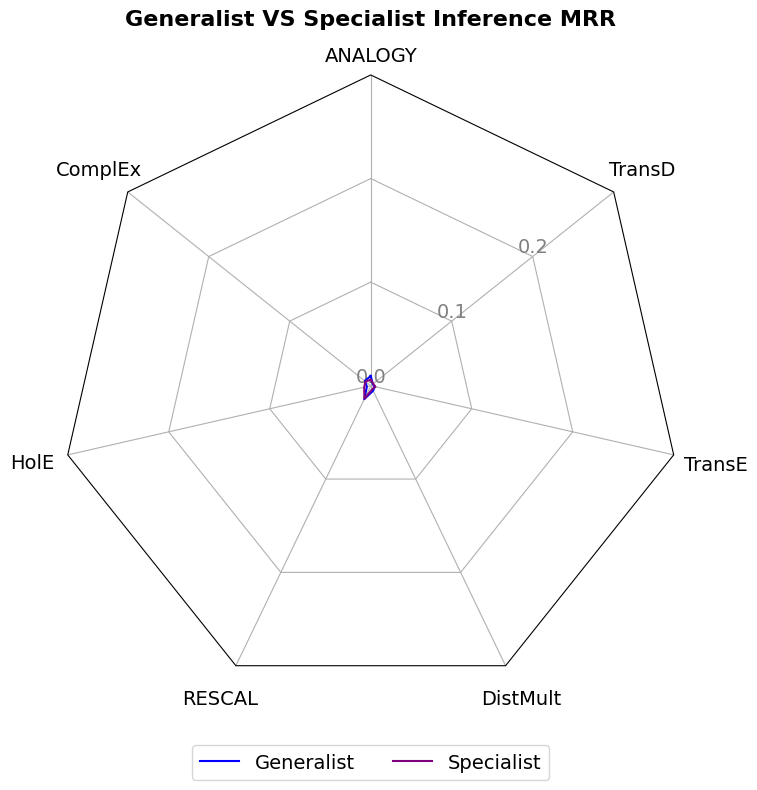

In [10]:
experiment1 = "without_dl1"  
experiment2 = "without_dl1_indication"
run = "run1" 
metric1 = "inference_mrr"
title = "Generalist VS Specialist Inference MRR"
y_lim=0.3
labels = ["Generalist", "Specialist"]
colors = ("blue", "purple")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
)


./radar_without_dl1_indication_vs_zero_shot_target_relations_run1.svg


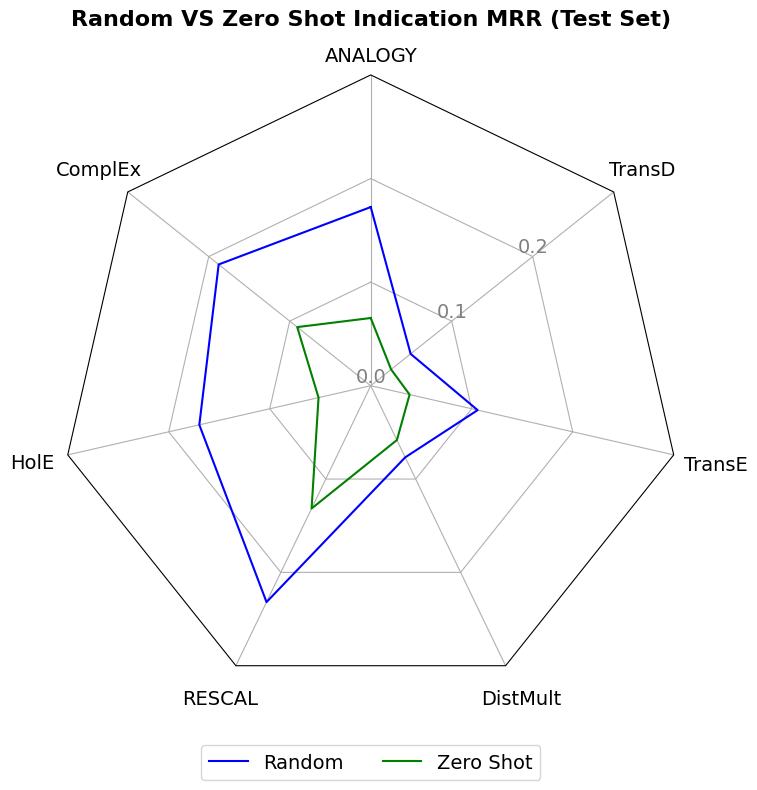

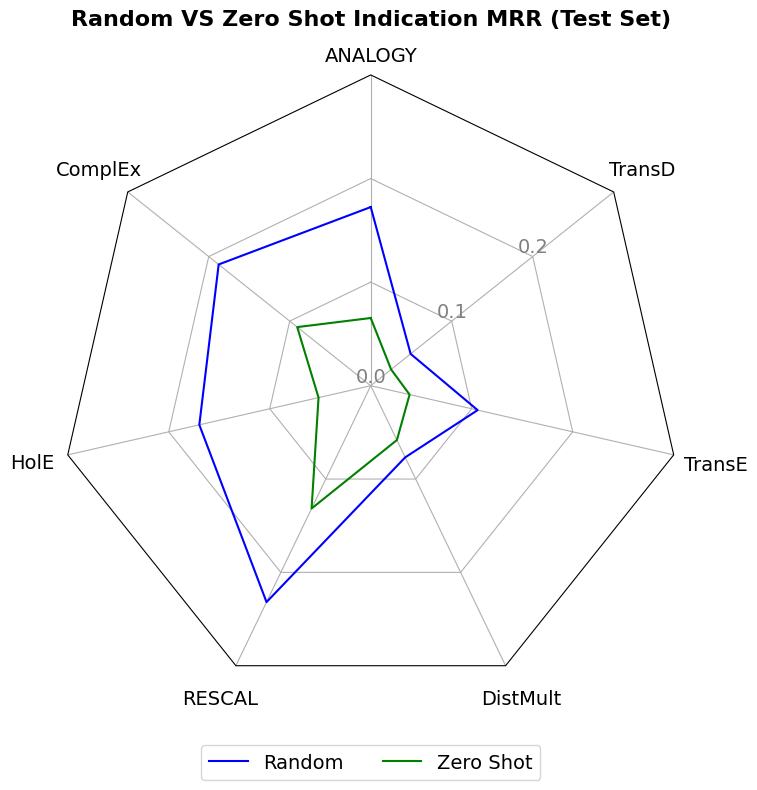

In [11]:
experiment1 = "without_dl1_indication"  
experiment2 = "zero_shot"
run = "run1" 
metric1 = "target_relations"
title = "Random VS Zero Shot Indication MRR (Test Set)"
y_lim=0.3
labels = ["Random", "Zero Shot"]
colors = ("blue", "green")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
)


./radar_without_dl1_indication_vs_zero_shot_inference_mrr_run1.svg


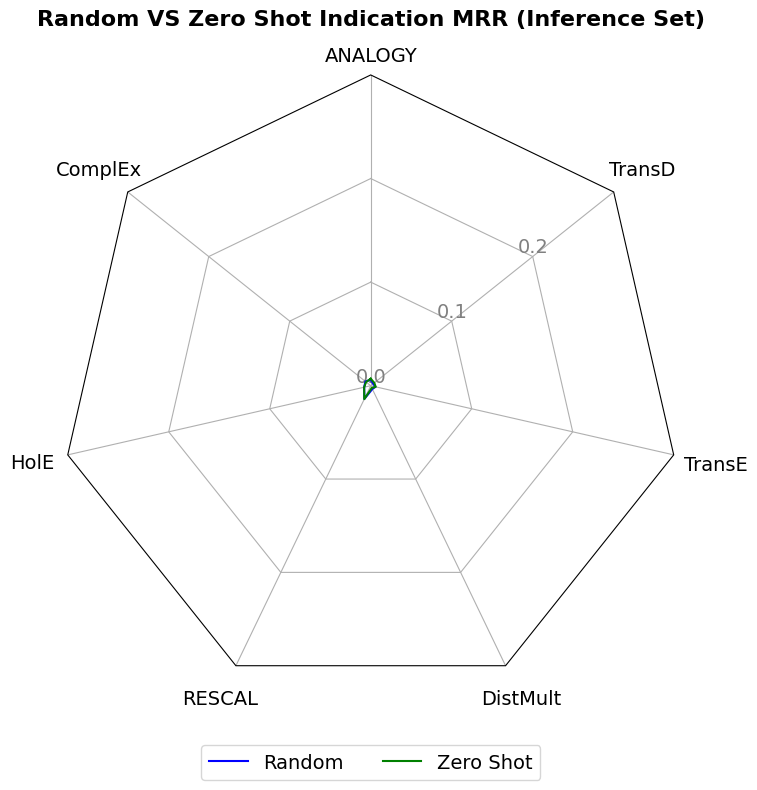

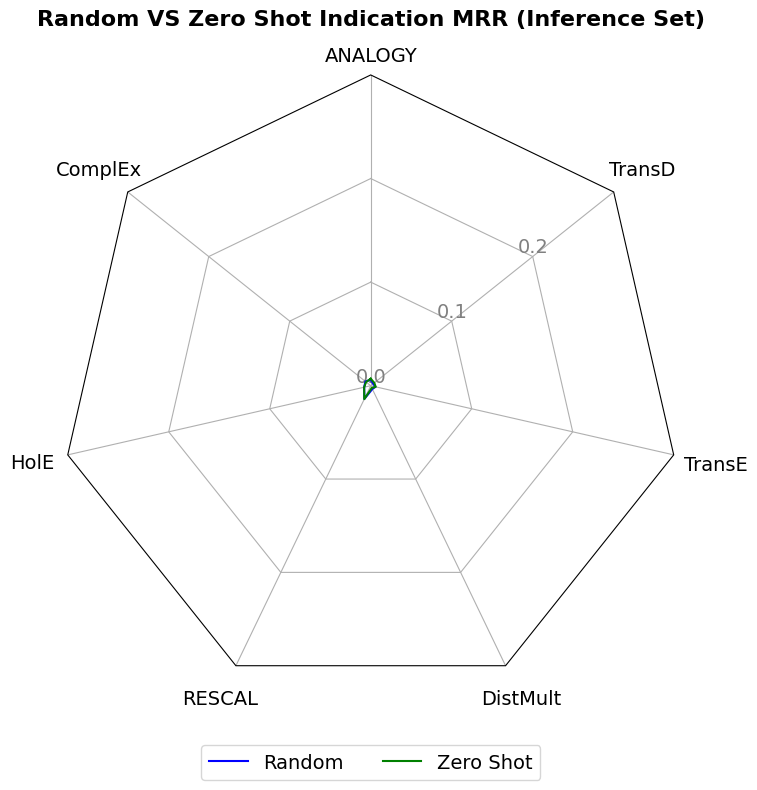

In [12]:
experiment1 = "without_dl1_indication"  
experiment2 = "zero_shot"
run = "run1" 
metric1 = "inference_mrr"
title = "Random VS Zero Shot Indication MRR (Inference Set)"
y_lim=0.3
labels = ["Random", "Zero Shot"]
colors = ("blue", "green")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
)
